In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron as SklearnPerceptron


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
file_path = "/content/drive/My Drive/neural_networks./train.csv"
df = pd.read_csv(file_path)
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

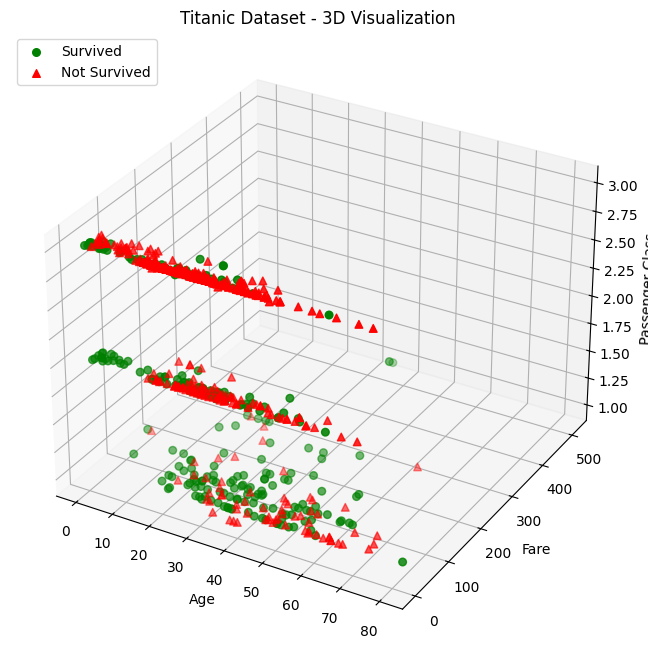

In [11]:
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection='3d')

survived = df[df['Survived'] == 1]
not_survived = df[df['Survived'] == 0]

ax.scatter(survived['Age'], survived['Fare'], survived['Pclass'],
           color='green', marker='o', s=30, edgecolor='green', label='Survived')
ax.scatter(not_survived['Age'], not_survived['Fare'], not_survived['Pclass'],
           color='red', marker='^', s=30, edgecolor='red', label='Not Survived')

ax.set_title('Titanic Dataset - 3D Visualization')
ax.set_xlabel('Age')
ax.set_ylabel('Fare')
ax.set_zlabel('Passenger Class')
plt.legend(loc='upper left')
plt.show()

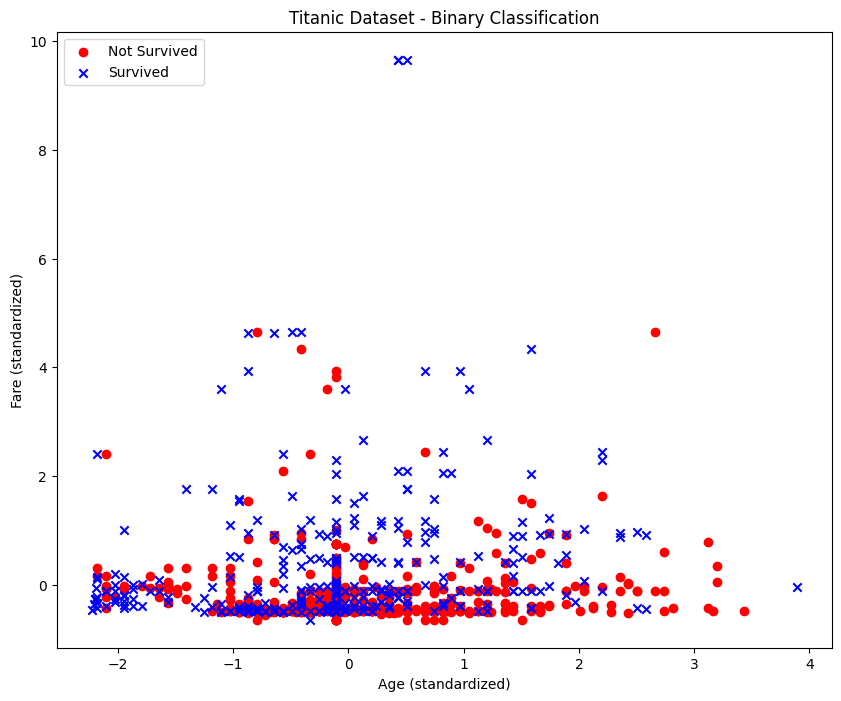

In [12]:
# Reduce to 2 features for visualization
X_2d = df[['Age', 'Fare']].copy()
y_2d = df['Survived'].copy()

# Handle missing values
X_2d['Age'] = X_2d['Age'].fillna(X_2d['Age'].median())
X_2d['Fare'] = X_2d['Fare'].fillna(X_2d['Fare'].median())

# Standardize
X_2d_scaled = (X_2d - X_2d.mean()) / X_2d.std()

plt.figure(figsize=(10, 8))
plt.scatter(X_2d_scaled[y_2d==0]['Age'], X_2d_scaled[y_2d==0]['Fare'],
            color='red', marker='o', label='Not Survived')
plt.scatter(X_2d_scaled[y_2d==1]['Age'], X_2d_scaled[y_2d==1]['Fare'],
            color='blue', marker='x', label='Survived')
plt.xlabel("Age (standardized)")
plt.ylabel("Fare (standardized)")
plt.legend(loc='upper left')
plt.title('Titanic Dataset - Binary Classification')
plt.show()

In [13]:
def preprocess_titanic(df, is_train=True):
    df_copy = df.copy()

    df_copy['Age'] = df_copy['Age'].fillna(df_copy['Age'].median())
    df_copy['Embarked'] = df_copy['Embarked'].fillna(df_copy['Embarked'].mode()[0])
    df_copy['Fare'] = df_copy['Fare'].fillna(df_copy['Fare'].median())

    df_copy['FamilySize'] = df_copy['SibSp'] + df_copy['Parch'] + 1
    df_copy['IsAlone'] = (df_copy['FamilySize'] == 1).astype(int)

    df_copy['Title'] = df_copy['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
    title_mapping = {
        'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
        'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
        'Mlle': 'Miss', 'Mme': 'Mrs', 'Ms': 'Miss', 'Lady': 'Rare',
        'Countess': 'Rare', 'Capt': 'Rare', 'Sir': 'Rare', 'Don': 'Rare',
        'Jonkheer': 'Rare'
    }
    df_copy['Title'] = df_copy['Title'].map(title_mapping)

    df_copy['Sex'] = df_copy['Sex'].map({'male': 0, 'female': 1})
    df_copy['Embarked'] = df_copy['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    df_copy = pd.get_dummies(df_copy, columns=['Title'], prefix='Title')

    columns_to_drop = ['Name', 'Ticket', 'Cabin', 'PassengerId']
    if is_train:
        columns_to_drop.append('Survived')
    df_copy = df_copy.drop(columns=[col for col in columns_to_drop if col in df_copy.columns])

    return df_copy

df_processed = preprocess_titanic(df, is_train=True)
print(df_processed.head())
print(df_processed.columns.tolist())

   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  FamilySize  IsAlone  \
0       3    0  22.0      1      0   7.2500         0           2        0   
1       1    1  38.0      1      0  71.2833         1           2        0   
2       3    1  26.0      0      0   7.9250         0           1        1   
3       1    1  35.0      1      0  53.1000         0           2        0   
4       3    0  35.0      0      0   8.0500         0           1        1   

   Title_Master  Title_Miss  Title_Mr  Title_Mrs  Title_Rare  
0         False       False      True      False       False  
1         False       False     False       True       False  
2         False        True     False      False       False  
3         False       False     False       True       False  
4         False       False      True      False       False  
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rar

X shape: (891, 9)
y shape: (891,)
Mean after scaling: [-8.77213254e-17  3.98733297e-17  2.27277979e-16  4.38606627e-17
  5.38289951e-17]
Std after scaling: [1. 1. 1. 1. 1.]


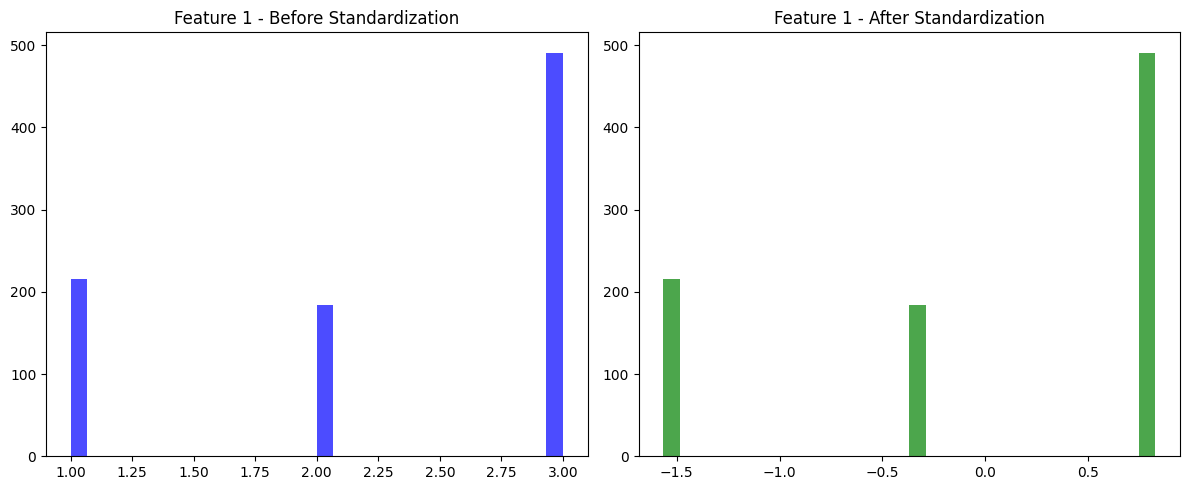

In [14]:
X = df_processed.select_dtypes(include=[np.number]).values
y = df['Survived'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Manual standardization (as in presentation)
x_mean = X.mean(axis=0)
x_std = X.std(axis=0)
X_scaled = (X - x_mean) / x_std

print(f"Mean after scaling: {X_scaled.mean(axis=0)[:5]}")
print(f"Std after scaling: {X_scaled.std(axis=0)[:5]}")

# Distribution before standardization (as shown in presentation)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(X[:, 0], bins=30, color='blue', alpha=0.7)
plt.title('Feature 1 - Before Standardization')
plt.subplot(1, 2, 2)
plt.hist(X_scaled[:, 0], bins=30, color='green', alpha=0.7)
plt.title('Feature 1 - After Standardization')
plt.tight_layout()
plt.show()

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Training survival rate: {y_train.mean()*100:.1f}%")
print(f"Test survival rate: {y_test.mean()*100:.1f}%")

Training samples: 623
Test samples: 268
Training survival rate: 38.4%
Test survival rate: 38.4%


In [16]:
class Perceptron:
    def __init__(self, learning_rate=0.1):
        self.learning_rate = learning_rate
        self._b = 0.0
        self._w = None
        self.misclassified_samples = []

    def fit(self, X, y, n_iter=100):
        self._b = 0.0
        self._w = np.zeros(X.shape[1])
        self.misclassified_samples = []

        for _ in range(n_iter):
            errors = 0
            for xi, yi in zip(X, y):
                update = self.learning_rate * (yi - self.predict(xi))
                self._b += update
                self._w += update * xi
                errors += int(update != 0.0)
            self.misclassified_samples.append(errors)
            if errors == 0:
                print(f"Converged at epoch {_+1}")
                break

    def f(self, X):
        return np.dot(X, self._w) + self._b

    def predict(self, X):
        return np.where(self.f(X) >= 0, 1, -1)

In [17]:
y_train_binary = np.where(y_train == 0, -1, 1)

perceptron = Perceptron(learning_rate=0.1)
perceptron.fit(X_train, y_train_binary, n_iter=100)

print(f"Final weights: {perceptron._w}")
print(f"Final bias: {perceptron._b}")
print(f"Final training errors: {perceptron.misclassified_samples[-1]}")

Final weights: [-0.18320496  0.59015611 -0.69769929 -0.5277024  -0.11758251  0.39764772
 -0.8041449  -0.41940873 -0.64953787]
Final bias: -0.8
Final training errors: 173


In [18]:
y_pred_binary = perceptron.predict(X_test)
y_pred = np.where(y_pred_binary == -1, 0, 1)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy*100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

Test Accuracy: 73.51%
Confusion Matrix:
[[141  24]
 [ 47  56]]

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.75      0.85      0.80       165
    Survived       0.70      0.54      0.61       103

    accuracy                           0.74       268
   macro avg       0.72      0.70      0.71       268
weighted avg       0.73      0.74      0.73       268



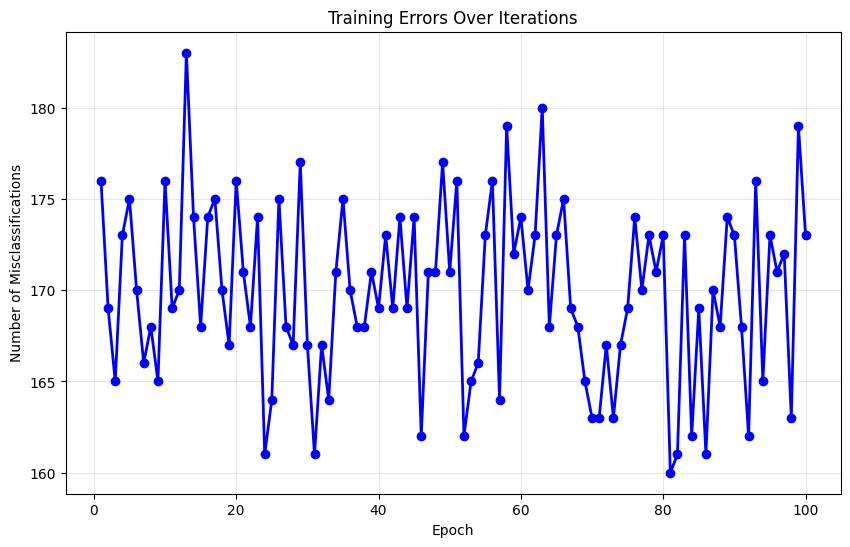

Initial errors: 176
Final errors: 173


In [19]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(perceptron.misclassified_samples) + 1),
         perceptron.misclassified_samples,
         color='blue', marker='o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Number of Misclassifications')
plt.title('Training Errors Over Iterations')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial errors: {perceptron.misclassified_samples[0]}")
print(f"Final errors: {perceptron.misclassified_samples[-1]}")

In [20]:
test_file_path = "/content/drive/My Drive/neural_networks./test.csv"
df_test = pd.read_csv(test_file_path)

passenger_ids = df_test['PassengerId']
df_test_processed = preprocess_titanic(df_test, is_train=False)

X_test_final = df_test_processed.select_dtypes(include=[np.number]).values
X_test_final_scaled = (X_test_final - x_mean) / x_std

predictions_binary = perceptron.predict(X_test_final_scaled)
predictions = np.where(predictions_binary == -1, 0, 1)

submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': predictions
})
submission.to_csv('submission.csv', index=False)
print(submission.head())
print(f"\nPrediction distribution:\n{submission['Survived'].value_counts()}")

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1

Prediction distribution:
Survived
0    308
1    110
Name: count, dtype: int64


In [21]:
sklearn_model = SklearnPerceptron(max_iter=100, eta0=0.1, random_state=42)
sklearn_model.fit(X_train, y_train)

sklearn_pred = sklearn_model.predict(X_test)
sklearn_accuracy = accuracy_score(y_test, sklearn_pred)

print(f"Sklearn Perceptron Accuracy: {sklearn_accuracy*100:.2f}%")
print(f"Custom Perceptron Accuracy: {accuracy*100:.2f}%")

Sklearn Perceptron Accuracy: 73.13%
Custom Perceptron Accuracy: 73.51%


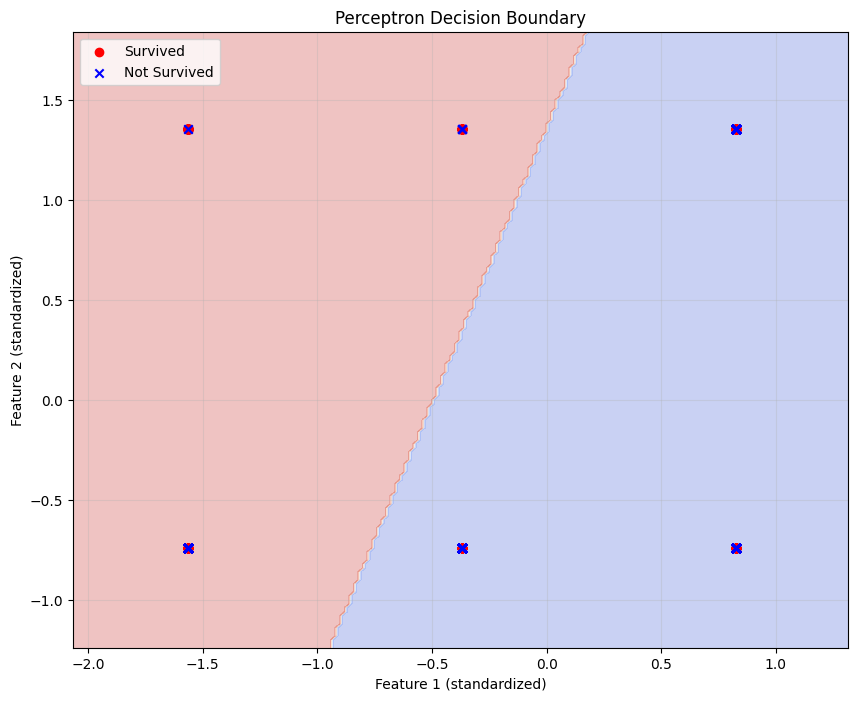

In [22]:
X_2d_train = X_train[:, :2]
y_train_2d = np.where(y_train == 0, -1, 1)

model_2d = Perceptron(learning_rate=0.1)
model_2d.fit(X_2d_train, y_train_2d, n_iter=100)

x_min, x_max = X_2d_train[:, 0].min() - 0.5, X_2d_train[:, 0].max() + 0.5
y_min, y_max = X_2d_train[:, 1].min() - 0.5, X_2d_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_2d_train[y_train==1, 0], X_2d_train[y_train==1, 1],
            color='red', marker='o', label='Survived')
plt.scatter(X_2d_train[y_train==0, 0], X_2d_train[y_train==0, 1],
            color='blue', marker='x', label='Not Survived')
plt.xlabel('Feature 1 (standardized)')
plt.ylabel('Feature 2 (standardized)')
plt.title('Perceptron Decision Boundary')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
print("="*60)
print("PERCEPTRON IMPLEMENTATION RESULTS")
print("="*60)
print(f"Dataset: Titanic - Machine Learning from Disaster")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Learning rate: {perceptron.learning_rate}")
print(f"Total epochs: {len(perceptron.misclassified_samples)}")
print(f"Initial training errors: {perceptron.misclassified_samples[0]}")
print(f"Final training errors: {perceptron.misclassified_samples[-1]}")
print(f"Test Accuracy: {accuracy*100:.2f}%")
print("="*60)

PERCEPTRON IMPLEMENTATION RESULTS
Dataset: Titanic - Machine Learning from Disaster
Training samples: 623
Test samples: 268
Number of features: 9
Learning rate: 0.1
Total epochs: 100
Initial training errors: 176
Final training errors: 173
Test Accuracy: 73.51%
